In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Entomology.csv")

# Preview data
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.358537e+09,134,i.imgur.com,16tz9u,I started drawing insects with patterns. Hope ...,Khmelic,146,12,16,http://www.reddit.com/r/Entomology/comments/16...,NaN,NaN,False,http://b.thumbs.redditmedia.com/WU3uX18u4N1bvI...,t5_2qygr,False,NaN,NaN,False,t3_16tz9u,http://i.imgur.com/vcSaD.png,NaN
1,1.358904e+09,124,i.imgur.com,173d9d,This coffee shop has beetle heads mounted on t...,mhy253,132,8,11,http://www.reddit.com/r/Entomology/comments/17...,NaN,NaN,False,http://c.thumbs.redditmedia.com/EBughV25uPmqLA...,t5_2qygr,False,NaN,NaN,False,t3_173d9d,http://i.imgur.com/rI2UOuA.jpg,NaN
2,1.350491e+09,107,pix.bay.to,11mwba,Climaciella brunnea.. AKA- lacewing pretending...,DrDendro,113,6,13,http://www.reddit.com/r/Entomology/comments/11...,NaN,NaN,False,http://b.thumbs.redditmedia.com/PdshjT5ufqmIjY...,t5_2qygr,False,NaN,NaN,False,t3_11mwba,http://pix.bay.to/albums/macro-2011-06-26-dair...,NaN
3,1.374055e+09,108,i.imgur.com,1ih6qa,Different stages of wasp development. From a n...,Skoalmintpouches,120,12,5,http://www.reddit.com/r/Entomology/comments/1i...,NaN,NaN,False,http://b.thumbs.redditmedia.com/81drQzndE0Ahpy...,t5_2qygr,False,NaN,NaN,False,t3_1ih6qa,http://i.imgur.com/peA4l16.jpg,NaN
4,1.355460e+09,110,i.imgur.com,14tsgb,An ant farm-style hornet's nest on my company'...,fishyfishkins,117,7,6,http://www.reddit.com/r/Entomology/comments/14...,NaN,NaN,False,http://d.thumbs.redditmedia.com/MNcjRpDWB29rfY...,t5_2qygr,False,NaN,NaN,False,t3_14tsgb,http://i.imgur.com/ZLy2U.jpg,NaN


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  955 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                62 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      45
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   938
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              999
dtype: int64

In [4]:
df = df.dropna()  # or use fillna()

In [9]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X = df.drop("target", axis=1)
y = df["target"]

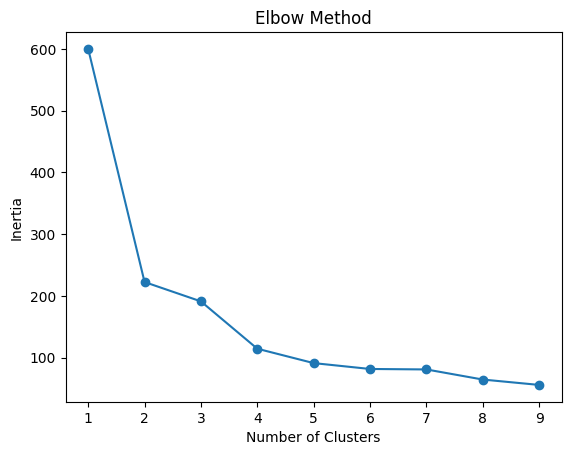

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [13]:
labels = kmeans.fit_predict(X)
# You must do this:
df["Cluster"] = labels

In [14]:
df.to_csv("Entomology_with_clusters.csv", index=False)